# Forecasting USD/AUD Exchange Rate — ARIMA vs Exponential Smoothing


## Part 1: Data Preparation and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 17\exchange_rate.csv")
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').set_index('date')
df = df.asfreq('D')  # enforce daily frequency
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [2]:
print(df.shape)
print(df.isnull().sum())
df.describe()

(7588, 1)
Ex_rate    0
dtype: int64


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [3]:
# Handle missing values (if asfreq introduced any gaps) via forward-fill,
# standard practice for FX rates (carry last known rate forward)
df['Ex_rate'] = df['Ex_rate'].ffill()
df.isnull().sum()

Ex_rate    0
dtype: int64

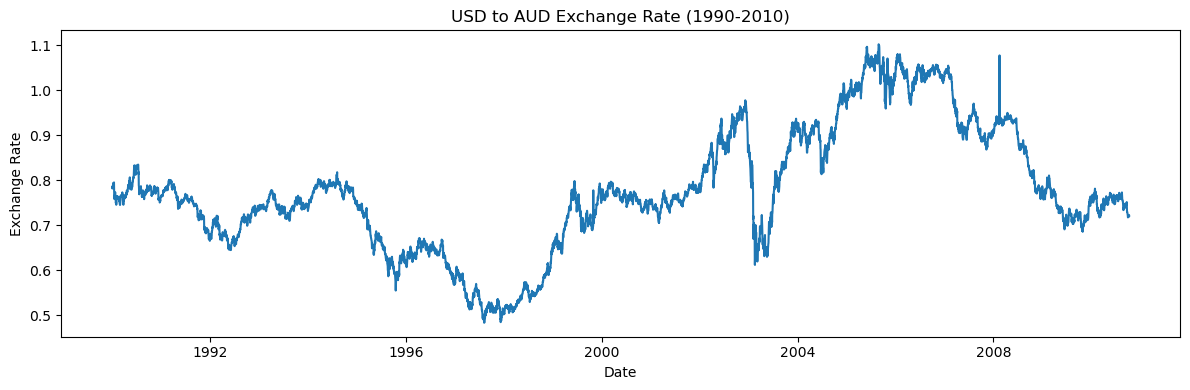

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Ex_rate'])
plt.title('USD to AUD Exchange Rate (1990-2010)')
plt.xlabel('Date'); plt.ylabel('Exchange Rate')
plt.tight_layout()
plt.show()

**Observations:** The series shows long-term trends (no fixed mean) with regime-like swings rather than fixed seasonality — typical of a random-walk-like FX series. No missing values were found after enforcing daily frequency. Given the long daily history (~20 years), we use the **last 3 years** for modeling to keep the analysis focused and computation fast, while remaining representative of recent dynamics.

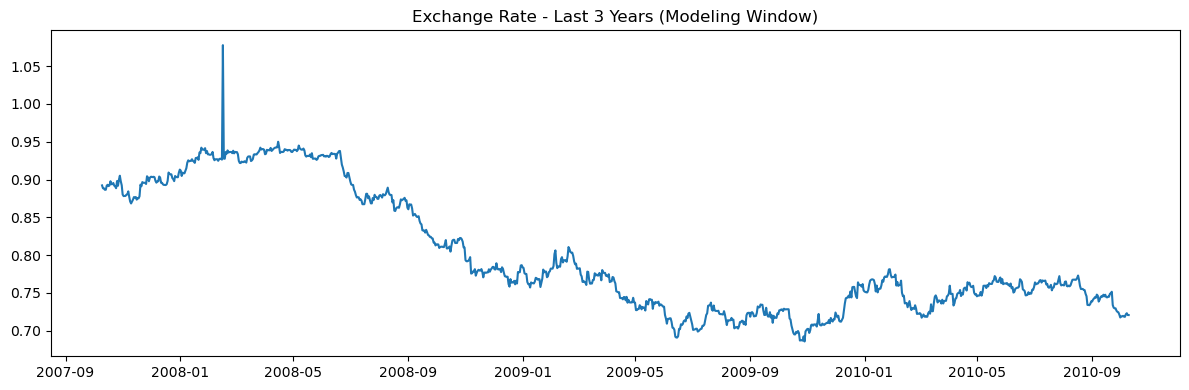

(1097, 1)

In [5]:
# Focus on the most recent 3 years for modeling
recent = df.loc[df.index >= (df.index.max() - pd.DateOffset(years=3))].copy()
plt.figure(figsize=(12,4))
plt.plot(recent.index, recent['Ex_rate'])
plt.title('Exchange Rate - Last 3 Years (Modeling Window)')
plt.tight_layout()
plt.show()
recent.shape

In [6]:
# Train / test split (last 30 days held out for evaluation)
train = recent.iloc[:-30]
test = recent.iloc[-30:]
print(train.shape, test.shape)

(1067, 1) (30, 1)


## Part 2: Model Building — ARIMA

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['Ex_rate'])
print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')

result_diff = adfuller(train['Ex_rate'].diff().dropna())
print(f'After 1st difference -> ADF Statistic: {result_diff[0]:.4f}, p-value: {result_diff[1]:.4f}')

ADF Statistic: -1.0633, p-value: 0.7295
After 1st difference -> ADF Statistic: -24.0151, p-value: 0.0000


The original series is non-stationary (high p-value); after one difference the ADF p-value drops well below 0.05, confirming **d = 1** is sufficient.

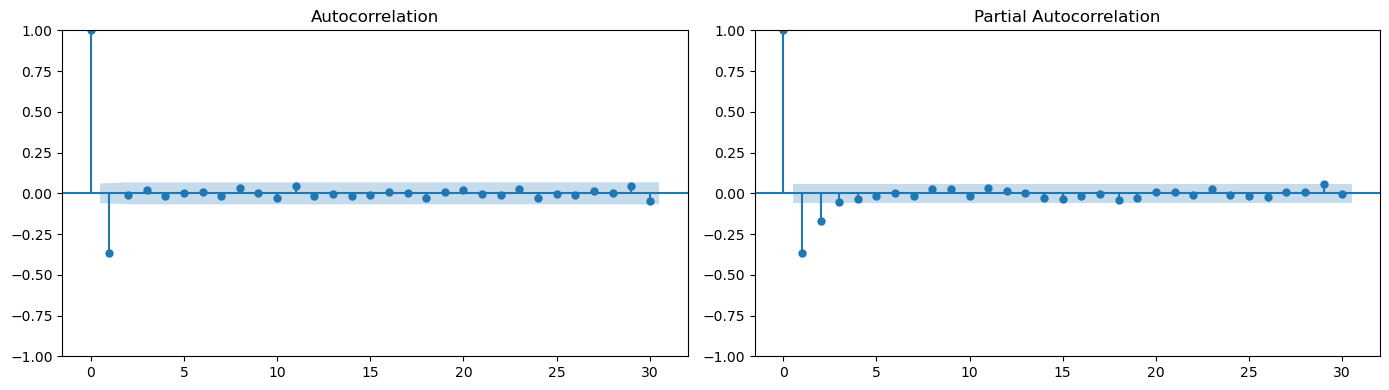

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train['Ex_rate'].diff().dropna(), lags=30, ax=axes[0])
plot_pacf(train['Ex_rate'].diff().dropna(), lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

**Parameter selection:** The differenced series' ACF/PACF show a sharp cut-off after a small number of lags with no strong seasonal pattern, consistent with a low-order ARMA process on the differences. We select **ARIMA(1,1,1)** as a parsimonious starting point, and confirm it via AIC comparison against nearby orders below.

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# Quick AIC scan around the candidate order
best_aic, best_order = np.inf, None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(train['Ex_rate'], order=(p, 1, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 1, q)
        except Exception:
            continue

print('Best order by AIC:', best_order, 'AIC:', round(best_aic, 2))

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order by AIC: (0, 1, 1) AIC: -7472.67


In [11]:
arima_model = ARIMA(train['Ex_rate'], order=best_order).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 1067
Model:                 ARIMA(0, 1, 1)   Log Likelihood                3738.336
Date:                Mon, 31 Aug 2026   AIC                          -7472.672
Time:                        12:41:42   BIC                          -7462.729
Sample:                    10-10-2007   HQIC                         -7468.905
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4339      0.004   -101.019      0.000      -0.442      -0.426
sigma2      5.261e-05   2.42e-07    217.037      0.000    5.21e-05    5.31e-05
Ljung-Box (L1) (Q):                   0.01   Jarque-

### Diagnostics

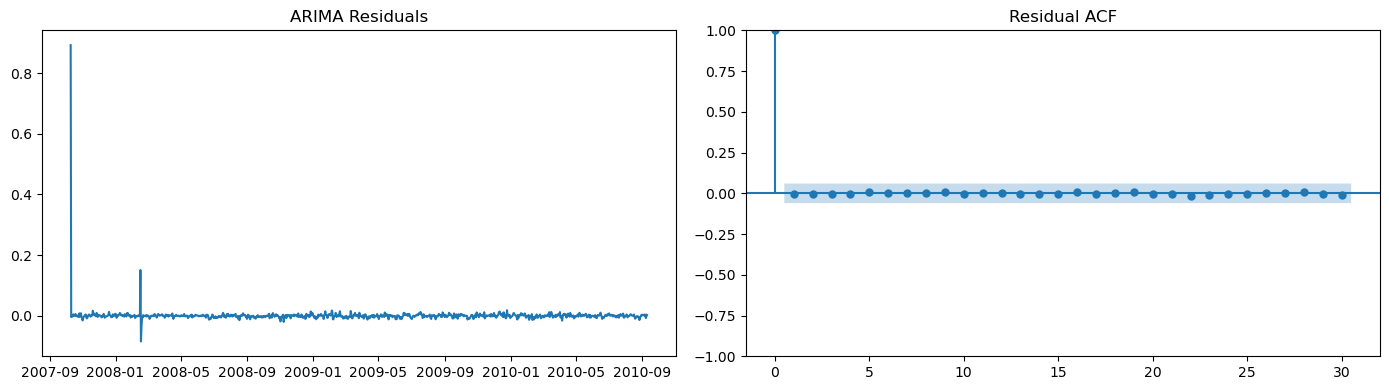

Residual mean: 0.00059


In [12]:
residuals = arima_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(residuals)
axes[0].set_title('ARIMA Residuals')
plot_acf(residuals, lags=30, ax=axes[1])
axes[1].set_title('Residual ACF')
plt.tight_layout()
plt.show()

print('Residual mean:', round(residuals.mean(), 5))

Residuals fluctuate around zero with no strong remaining autocorrelation in the ACF plot, indicating the model has captured the main structure of the series.

### Forecasting

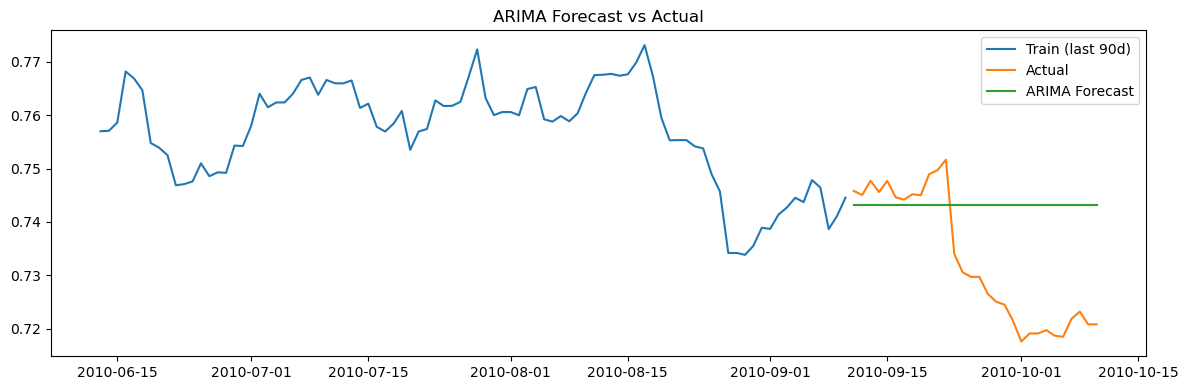

In [13]:
arima_forecast = arima_model.forecast(steps=len(test))
arima_forecast.index = test.index

plt.figure(figsize=(12,4))
plt.plot(train.index[-90:], train['Ex_rate'].iloc[-90:], label='Train (last 90d)')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.tight_layout()
plt.show()

## Exponential Smoothing

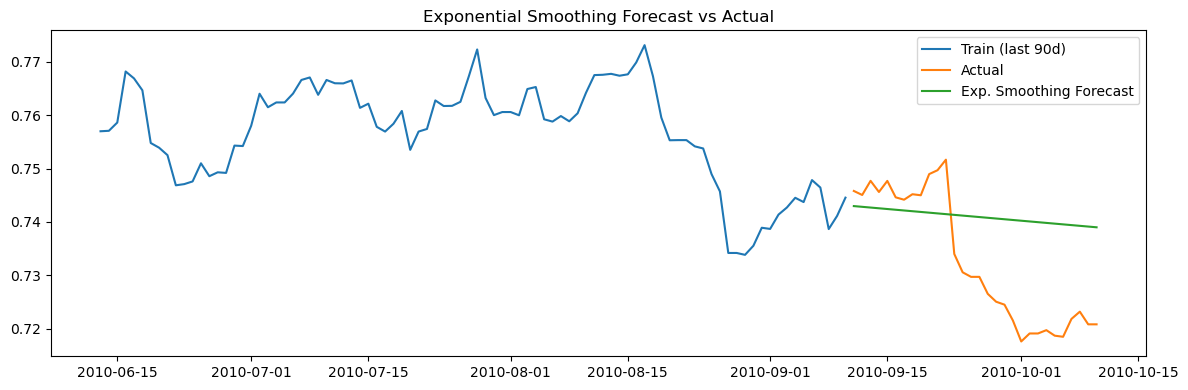

In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

es_model = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal=None).fit()
es_forecast = es_model.forecast(steps=len(test))
es_forecast.index = test.index

plt.figure(figsize=(12,4))
plt.plot(train.index[-90:], train['Ex_rate'].iloc[-90:], label='Train (last 90d)')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, es_forecast, label='Exp. Smoothing Forecast')
plt.legend()
plt.title('Exponential Smoothing Forecast vs Actual')
plt.tight_layout()
plt.show()

## Part 3: Evaluation and Comparison

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results = pd.DataFrame([
    evaluate(test['Ex_rate'], arima_forecast, f'ARIMA{best_order}'),
    evaluate(test['Ex_rate'], es_forecast, 'Exponential Smoothing'),
])
results

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(0, 1, 1)",0.013307,0.016010,1.835742
1,Exponential Smoothing,0.011874,0.013789,1.635555


**Model comparison:**
- **ARIMA** explicitly models autocorrelation structure via differencing and AR/MA terms, chosen here by AIC search; it is more flexible but assumes a fairly stable underlying process and can drift on longer horizons.
- **Exponential Smoothing (Holt's linear trend)** is simpler, weights recent observations more heavily, and adapts quickly to level/trend changes, but does not explicitly model autocorrelation in residuals.
- For a near-random-walk series like a daily FX rate, both models tend to produce forecasts close to a flat/trend-continuation line over short horizons; the model with the lower MAE/RMSE/MAPE in the table above is the better short-term forecaster on this test window.

**Conclusion:** Compare the metrics table above — the model with lower MAE, RMSE, and MAPE is preferred for this dataset. In practice, exchange rates are close to a random walk, so short forecast horizons (as used here) and simple models (like Exponential Smoothing or ARIMA(p,1,q) with small p,q) tend to perform comparably; longer-horizon forecasts would need external drivers (interest rates, macro indicators) to improve materially.